# Buổi 8: Bài toán phân cụm

In [108]:
import numpy as np
import random, os
from IPython import display

import matplotlib.pyplot as plt          # vẽ hình
from collections import Counter

import pandas as pd
from sklearn.datasets import make_blobs  # tạo tập điểm phân bố Gaussian
from sklearn.cluster import KMeans       # thuật toán phân cụm k-means

import warnings
warnings.filterwarnings("ignore")

# cố định random-state để phục hồi lại kết quả thí nghiệm
random_state = 42
random.seed(random_state)
os.environ['PYTHONHASHSEED'] = str(random_state)
np.random.seed(random_state)

## Bài 1. Tập hợp điểm hai chiều

### 1. Tạo và hiển thị dữ liệu

Tạo và hiển thị tập hợp điểm dữ liệu $X_1$ có chứa $N=400$ điểm hai chiều. Những tập hợp này bao gồm 4 nhóm bằng nhau, mỗi nhóm có hàm mật độ theo phân phối Gaussian với mean $m_0=\left(0, 0\right)$, $m_1=\left(10, 0\right)$, $m_2=\left(0, 9\right)$, và $m_3=\left(9, 8\right)$ và ma trận covariance tương ứng $S_0=I$, $S_1=1.5I$, $S_2=1.1I$, và $S_3=0.5I$ nơi mà $
I = \begin{bmatrix}
 1 & 1\\ 
 1 & 1
\end{bmatrix}.
$

**Lưu ý**: 
+ **mean** là tâm của tập hợp điểm
+ **covariance** cho biết độ biến đổi của tập điểm xung quanh tâm. Giá trị càng lớn thì độ phân tán so với tâm càng xa và ngược lại.

In [109]:
# Sinh tập hợp điểm theo phân phối Gaussian
X1, y1 = make_blobs(n_samples    = 400,                         # số lượng điểm
                    centers      = [[0,0], [10,0],[0,9],[9,8]], # vị trí tâm
                    cluster_std  = [1, 1.5, 1.1, 0.5],          # độ phân tán
                    random_state = random_state,                # seed ngẫu nhiên
                   )

In [110]:
# lưu trữ trong pandas
df_points = pd.DataFrame(X1, columns=["x", "y"])
df_points["label"] = y1

# tính số lớp, tần số xuất hiện mỗi lớp
n_classes = len(np.unique(df_points["label"])) # tính số lớp dữ liệu
labels, cnts = np.unique(df_points["label"], return_counts=True)
n_cnts = dict(zip(labels, cnts))
print(f'+ labels={labels}\n+ cnts={cnts}\n+ n_cnts={n_cnts}')

# hiển thị dữ liệu
display.display(df_points)

+ labels=[0 1 2 3]
+ cnts=[100 100 100 100]
+ n_cnts={np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}


,x,y,label
0,0.372346,8.543183,2
1,-0.495072,9.685135,2
2,8.738638,8.524505,3
3,9.014159,8.014878,3
4,8.505198,7.937107,3
...,...,...,...
395,11.120940,0.915555,1
396,11.022929,-0.465400,1
397,-1.150994,0.375698,0
398,-2.718809,8.123415,2


Center 0: [-0.11556425  0.03402232]
Center 1: [10.19237309  0.06523147]
Center 2: [-0.04954113  8.86110005]
Center 3: [8.96175896 8.04720768]


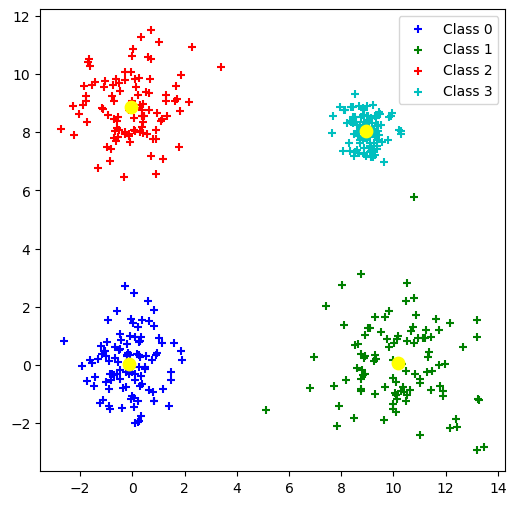

In [111]:
# màu của từng lớp
colors = {0:'b', 1:'g',2:'r',3:'c', 4:'m', 5:'y', 6:'k', 7:'w'} 

# vẽ tập dữ liệu điểm
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(n_classes):
    # tính toán điểm trung tâm từng lớp
    p_center = np.mean(X1[y1==i], axis = 0) 
    print(f'Center {i}: {p_center}')
    # vẽ tập điểm
    plt.scatter(X1[y1==i, 0], X1[y1==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(p_center[0], p_center[1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 2. Áp dụng thuật toán phân cụm

Thuật toán k-mean chia tập hợp $N$ mẫu $X_1$ thành $m$ cụm rời rạc $C$ (clusters), mỗi cụm được mô tả bằng giá trị trung bình của các mẫu trong cụm (thường được gọi là trung tâm cụm - centroid).

Thuật toán k-mean hướng tới chọn các centroids sao cho cực tiểu hóa độ đo khoảng cách (intertia) giữa các phần tử trong cụm (within-cluster). Độ đo hay dùng là tổng bình phương khoảng cách theo Euclide distance.

####  2.1. Số cụm m = 4 ngẫu nhiên

In [112]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels  = sum(y1 == y_pred) # tính độ chính xác

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

Centers:
[[ 1.01865125e+01  7.51565800e-03]
 [-4.95411256e-02  8.86110005e+00]
 [-1.15564255e-01  3.40223244e-02]
 [ 8.97968780e+00  8.02475114e+00]]
Inertia: 870.6509324177754
Correct Labels: 100 / 400
Accuracy score: 0.25


**Lưu ý**:
+ Intertia là độ đo khoảng cách giữa các phần tử trong cụm. Giá trị càng nhỏ là càng tốt và tiến tới 0 là tốt nhất.
+ Chúng ta chỉ đạt được độ chính xác thấp 25% do đây là mô hình unsupervised (học không giám sát)

Predict: [1 1 3 3 3 3 1 0 2 2 1 2 3 2 2 2 1 0 2 0] ...
Center 0: [1.01865125e+01 7.51565800e-03]
Center 1: [-0.04954113  8.86110005]
Center 2: [-0.11556425  0.03402232]
Center 3: [8.9796878  8.02475114]


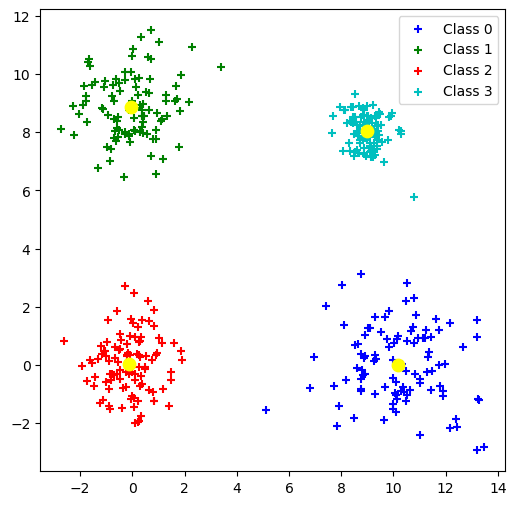

In [113]:
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

####  2.2. Số cụm m = 3 ngẫu nhiên

Centers:
[[ 9.59937239  4.08432411]
 [-0.04954113  8.86110005]
 [-0.06354779  0.01847179]]
Inertia: 4135.476824302053
Correct Labels: 0 / 400
Accuracy score: 0.00

Predict: [1 1 0 0 0 0 1 0 2 2 1 2 0 2 2 2 1 0 2 0] ...
Center 0: [9.59937239 4.08432411]
Center 1: [-0.04954113  8.86110005]
Center 2: [-0.06354779  0.01847179]


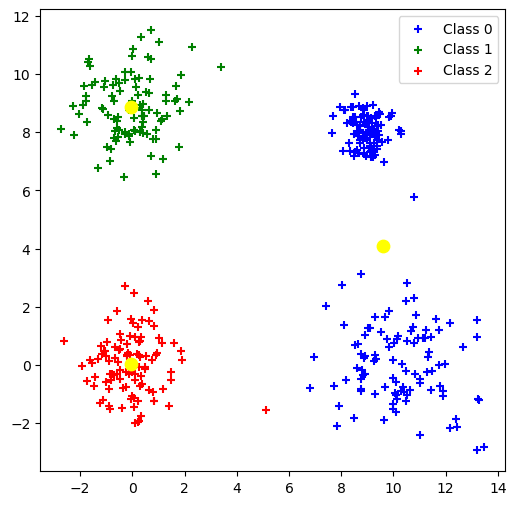

In [114]:
m = 3 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.3. Số cụm m = 5 ngẫu nhiên

Centers:
[[ 8.99671126  0.04820064]
 [-0.04954113  8.86110005]
 [-0.11556425  0.03402232]
 [ 8.9796878   8.02475114]
 [11.45067631 -0.03571213]]
Inertia: 721.5705553973448
Correct Labels: 100 / 400
Accuracy score: 0.25

Predict: [1 1 3 3 3 3 1 4 2 2 1 2 3 2 2 2 1 0 2 4] ...
Center 0: [8.99671126 0.04820064]
Center 1: [-0.04954113  8.86110005]
Center 2: [-0.11556425  0.03402232]
Center 3: [8.9796878  8.02475114]
Center 4: [11.45067631 -0.03571213]


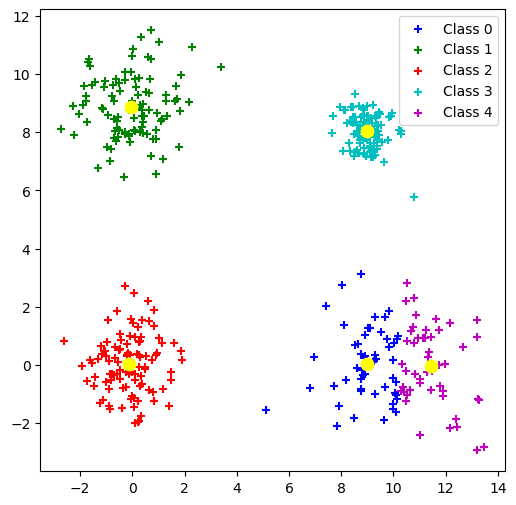

In [115]:
m = 5 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.4. Số cụm m = 4 xác định trước

Tập $m=4$ cụm xác định trước lần lượt là $\theta_1 = \left(-2, -2\right)$, $\theta_2 = \left(-2.1, -2.1\right)$, $\theta_3 = \left(-2.0, -2.2\right)$, $\theta_4 = \left(-2.1, -2.2\right)$

Centers:
[[-1.15564255e-01  3.40223244e-02]
 [-4.95411256e-02  8.86110005e+00]
 [ 1.01865125e+01  7.51565800e-03]
 [ 8.97968780e+00  8.02475114e+00]]
Inertia: 870.6509324177754
Correct Labels: 200 / 400
Accuracy score: 0.50

Predict: [1 1 3 3 3 3 1 2 0 0 1 0 3 0 0 0 1 2 0 2] ...
Center 0: [-0.11556425  0.03402232]
Center 1: [-0.04954113  8.86110005]
Center 2: [1.01865125e+01 7.51565800e-03]
Center 3: [8.9796878  8.02475114]


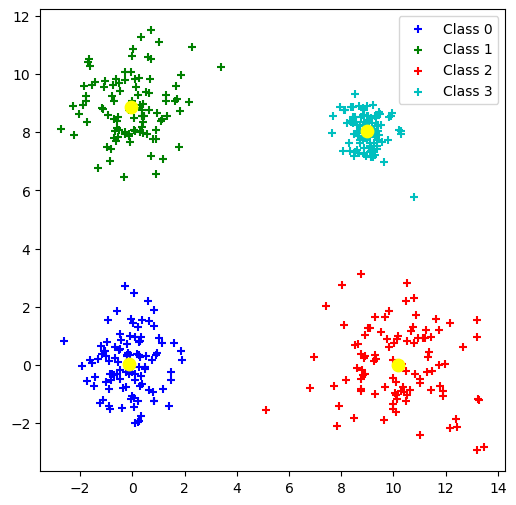

In [116]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, 
                init = np.array([[-2,-2], [-2.1, -2.1], [-2.0, -2.2], [-2.1,-2.2]]),
                n_init = 1, # chỉ chạy 1 lần k_means
                random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 3. Tìm số lượng cụm tối ưu bởi điểm cong (elbow method)

+ Chúng ta thực hiện k-means nhiều lần với k=2, 3, ... 
+ Vẽ đồ thị độ đo khoảng cách giữa các phần tử trong cụm
+ Tìm điểm cong quan trọng của đồ thị

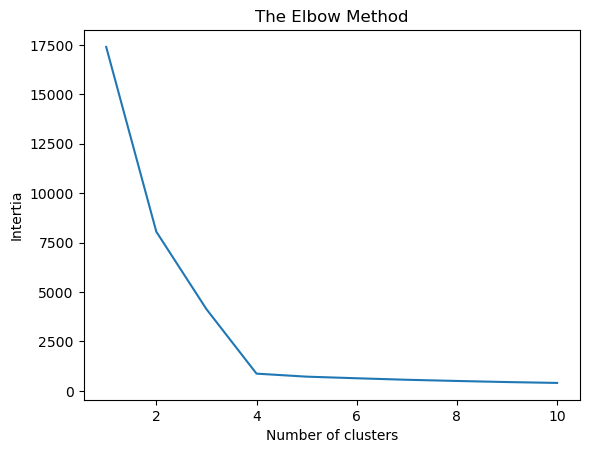

In [117]:
list_intertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i,      # số cluster
                    init = 'k-means++',  # khởi tạo ngẫu nhiên dùng k-means++
                    max_iter = 300,      # số lần lặp trong thuật toán
                    n_init = 10,         # số lần chạy lại k-means và lấy tốt nhất
                    random_state = random_state,
                   )
    kmeans.fit(X1)
    list_intertia.append(kmeans.inertia_)
plt.plot(range(1, 11), list_intertia)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Intertia')
plt.show()

+ Hình trên cho thấy số lượng cluster tối ưu là 4

## Bài 3. Bài tập áp dụng

Áp dụng thuật toán k-means cho tập dữ liệu sau:
+ Tập điểm dữ liệu $X_2$ gồm 400 điểm 2 chiều chứa 4 lớp với số lượng phần tử bằng nhau. Các tập hợp điểm trong lớp tuân theo phân phối Gaussian với means $m_0=\left(0, 0\right)$, $m_1=\left(4, 0\right)$, $m_2=\left(0, 4\right)$, và $m_3=\left(5, 4\right)$ với các covariance matrices tương ứng $S_0=I$, $S_1=1.5I$, $S_2=1.1I$, $S_3=0.5I$.

+ Tập điểm dữ liệu $X_3$ gồm 300 điểm 2 chiều chỉ có 1 lớp dữ liệu với mean $m_1=\left(0, 0\right)$ và $S_1 = I$.

## Tạo dữ liệu

In [118]:
n_per_class = 100

m0, m1, m2, m3 = [0, 0], [4, 0], [0, 4], [5, 4]
S0 = np.eye(2)
S1 = 1.5 * np.eye(2)
S2 = 1.1 * np.eye(2)
S3 = 0.5 * np.eye(2)

X2_0 = np.random.multivariate_normal(m0, S0, n_per_class)
X2_1 = np.random.multivariate_normal(m1, S1, n_per_class)
X2_2 = np.random.multivariate_normal(m2, S2, n_per_class)
X2_3 = np.random.multivariate_normal(m3, S3, n_per_class)

X2 = np.vstack([X2_0, X2_1, X2_2, X2_3])
y2_true = np.array([0]*100 + [1]*100 + [2]*100 + [3]*100)

# --- Tập X3: 300 điểm, 1 lớp ---
m1_x3 = [0, 0]
S1_x3 = np.eye(2)
X3 = np.random.multivariate_normal(m1_x3, S1_x3, 300)

## Vẽ dữ liệu gốc

In [119]:
import os

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Dữ liệu gốc", fontsize=14, fontweight='bold')

colors_true = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, c in enumerate(colors_true):
    mask = y2_true == i
    axes[0].scatter(X2[mask, 0], X2[mask, 1], c=c, s=20, alpha=0.7, label=f'Lớp {i}')
axes[0].set_title("X2 - 4 lớp (dữ liệu gốc)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X3[:, 0], X3[:, 1], c='tab:purple', s=20, alpha=0.7)
axes[1].set_title("X3 - 1 lớp (dữ liệu gốc)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Create output directory if it doesn't exist
output_dir = "/mnt/user-data/outputs"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "01_du_lieu_goc.png"), dpi=130, bbox_inches='tight')
plt.close()
print("✔ Đã lưu: 01_du_lieu_goc.png")

✔ Đã lưu: 01_du_lieu_goc.png


## kmean x2

In [120]:
k_values = [2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle("X2 - K-Means với k = 2, 3, 4, 5", fontsize=14, fontweight='bold')

cmap = plt.get_cmap('tab10')

for idx, k in enumerate(k_values):
    ax = axes[idx // 2][idx % 2]
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X2)
    centroids = km.cluster_centers_
    sse = km.inertia_

    for c in range(k):
        mask = labels == c
        ax.scatter(X2[mask, 0], X2[mask, 1], c=[cmap(c)], s=18, alpha=0.65, label=f'Cụm {c}')
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='black', marker='X', s=150, zorder=5, label='Centroid')
    ax.set_title(f"k = {k}  |  SSE = {sse:.1f}")
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/02_X2_kmeans_k2_k3_k4_k5.png", dpi=130, bbox_inches='tight')
plt.close()
print("✔ Đã lưu: 02_X2_kmeans_k2_k3_k4_k5.png")

✔ Đã lưu: 02_X2_kmeans_k2_k3_k4_k5.png


## elbow method x2

In [121]:
from sklearn.metrics import silhouette_score

sse_list_x2 = []
sil_list_x2 = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X2)
    sse_list_x2.append(km.inertia_)
    sil_list_x2.append(silhouette_score(X2, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("X2 - Elbow Method & Silhouette Score", fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), sse_list_x2, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(x=4, color='red', linestyle='--', label='Điểm cong tối ưu k=4')
axes[0].set_xlabel("Số cụm k")
axes[0].set_ylabel("SSE (Inertia)")
axes[0].set_title("Elbow Method - X2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_list_x2, 'gs-', linewidth=2, markersize=7)
axes[1].axvline(x=4, color='red', linestyle='--', label='k=4 tối ưu')
axes[1].set_xlabel("Số cụm k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score - X2")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/03_X2_elbow_silhouette.png", dpi=130, bbox_inches='tight')
plt.close()
print("✔ Đã lưu: 03_X2_elbow_silhouette.png")

✔ Đã lưu: 03_X2_elbow_silhouette.png


## kmean x3

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("X3 - K-Means với k = 2, 3, 4", fontsize=14, fontweight='bold')

for idx, k in enumerate([2, 3, 4]):
    ax = axes[idx]
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X3)
    centroids = km.cluster_centers_
    sse = km.inertia_

    for c in range(k):
        mask = labels == c
        ax.scatter(X3[mask, 0], X3[mask, 1], c=[cmap(c)], s=20, alpha=0.65, label=f'Cụm {c}')
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='black', marker='X', s=150, zorder=5, label='Centroid')
    ax.set_title(f"k = {k}  |  SSE = {sse:.1f}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/04_X3_kmeans.png", dpi=130, bbox_inches='tight')
plt.close()
print("✔ Đã lưu: 04_X3_kmeans.png")

✔ Đã lưu: 04_X3_kmeans.png


## elbow metthod x3

In [123]:
sse_list_x3 = []
sil_list_x3 = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X3)
    sse_list_x3.append(km.inertia_)
    sil_list_x3.append(silhouette_score(X3, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("X3 - Elbow Method & Silhouette Score", fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), sse_list_x3, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel("Số cụm k")
axes[0].set_ylabel("SSE (Inertia)")
axes[0].set_title("Elbow Method - X3 (không có điểm cong rõ)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_list_x3, 'gs-', linewidth=2, markersize=7)
axes[1].set_xlabel("Số cụm k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score - X3")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/05_X3_elbow_silhouette.png", dpi=130, bbox_inches='tight')
plt.close()
print("✔ Đã lưu: 05_X3_elbow_silhouette.png")

✔ Đã lưu: 05_X3_elbow_silhouette.png


## ket qua 

In [124]:
print("\n" + "="*55)
print("KẾT QUẢ TỔNG HỢP")
print("="*55)

print("\n[X2] SSE theo k:")
for k, sse in zip(K_range, sse_list_x2):
    print(f"  k={k}: SSE={sse:.2f}, Silhouette={sil_list_x2[k-2]:.4f}")

best_k_x2 = list(K_range)[np.argmax(sil_list_x2)]
print(f"\n→ Số cụm tối ưu X2 theo Silhouette: k = {best_k_x2}")

print("\n[X3] SSE theo k:")
for k, sse in zip(K_range, sse_list_x3):
    print(f"  k={k}: SSE={sse:.2f}, Silhouette={sil_list_x3[k-2]:.4f}")

best_k_x3 = list(K_range)[np.argmax(sil_list_x3)]
print(f"\n→ Số cụm tối ưu X3 theo Silhouette: k = {best_k_x3}")
print("\n[X3] Nhận xét: Dữ liệu chỉ có 1 lớp thực → k-means")
print("  sẽ ép phân chia tùy tiện, không có cụm tự nhiên.")
print("="*55)


KẾT QUẢ TỔNG HỢP

[X2] SSE theo k:
  k=2: SSE=2292.15, Silhouette=0.4619
  k=3: SSE=1435.09, Silhouette=0.4908
  k=4: SSE=698.87, Silhouette=0.5588
  k=5: SSE=618.34, Silhouette=0.4855
  k=6: SSE=536.12, Silhouette=0.4408
  k=7: SSE=483.47, Silhouette=0.3997
  k=8: SSE=432.92, Silhouette=0.3313
  k=9: SSE=386.14, Silhouette=0.3368

→ Số cụm tối ưu X2 theo Silhouette: k = 4

[X3] SSE theo k:
  k=2: SSE=375.20, Silhouette=0.3270
  k=3: SSE=253.62, Silhouette=0.3476
  k=4: SSE=197.27, Silhouette=0.3396
  k=5: SSE=163.19, Silhouette=0.3320
  k=6: SSE=136.39, Silhouette=0.3371
  k=7: SSE=118.90, Silhouette=0.3327
  k=8: SSE=102.35, Silhouette=0.3456
  k=9: SSE=93.10, Silhouette=0.3427

→ Số cụm tối ưu X3 theo Silhouette: k = 3

[X3] Nhận xét: Dữ liệu chỉ có 1 lớp thực → k-means
  sẽ ép phân chia tùy tiện, không có cụm tự nhiên.


# Kết thúc